<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/senior/try_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# df = pd.read_pickle('cluster38838_clustered_again.pkl')
df = pd.read_pickle('clusterd_all.pkl')
df = df.reset_index(drop=True)
df

,index,title,contents,date,token,vector,cluster
0,0,일월도서관 5060세대를 위한 인문학과 독서,프로그램명 세대를 위한 인문학과 독서 교육기간 매주 화 ...,2026. 2. 6. 15:16,"[프로그램, 세대, 위, 인문학, 독서, 교육, 기간, 총, 회, 장소, 일월, 도...","[0.081283905, -0.45355675, -0.13710701, 0.6700...",0
1,1,일월도서관 5060세대를 위한 인문학과 독서,프로그램명 세대를 위한 인문학과 독서 교육기간 매주 화 ...,2026. 2. 6. 15:16,"[프로그램, 세대, 위, 인문학, 독서, 교육, 기간, 총, 회, 장소, 일월, 도...","[-0.03853597, -0.42289045, -0.09204495, 0.7433...",0
2,2,"나는 무인매장으로 퇴사합니다 -5060무인매장 창업, 노후 파이프라인이 될 수 있을까?",나는무인매장으로퇴사합니다 무인매장창업 창업 무인매장고민 노후파이프라인 노후준비...,2026. 2. 12. 9:00,"[무인, 매장, 퇴사, 무인, 매장, 창업, 창업, 무인, 매장, 고민, 노후, 파...","[0.50095195, 0.24801755, -0.15919541, 0.450126...",0
3,3,"50대, 책장을 덮고 '나'를 읽기 시작할 때 : 다산 정약용이 말하는 중년의 독서법",학이불사즉망 사이불학즉태 배우기만 하고 생각하지 않으면 얻는 것이 없고 생각만 하...,2026. 2. 2. 21:34,"[학, 불사, 즉망, 불학, 즉태, 배우다, 생각, 얻다, 생각, 배우다, 위태, ...","[-0.05474087, -0.24375252, -0.13827604, -0.081...",0
4,4,약 없이 혈압 잡는 기적? 5060 시니어 혈압 관리 비법 3가지,안녕하세요 년 혈압 관리의 새로운 패러다임을 제시하는 글을 읽고 계십니다 이 포...,2026. 2. 24. 15:20,"[안녕하다, 혈압, 관리, 새롭다, 패러다임, 제시, 글, 읽다, 계시다, 포스팅,...","[0.17096868, -0.706551, 0.27657604, 0.21848677...",0
...,...,...,...,...,...,...,...
67769,67769,혈관 뻥‼️뚫는 음식 5가지 #심장질환 #심혈관질환 #건강 #건강정보 #콜레스테롤 ...,‼️무조건 혈관에 좋은 음식 5가지‼️\n\n콜레스테롤 수치가 높아지면 혈관의 노폐...,1년 전,"[무조건, 혈관, 좋다, 음식, 가지, 콜레스테롤, 수치, 높아지다, 혈관, 노폐물...","[-0.29768983, -0.7099835, 0.07757375, -0.15291...",2
67770,67770,&quot;60대 사망률 1위 뇌졸중&quot; 독소 찌꺼기 범벅 혈관 싹 씻기는 ...,​1. 뇌졸중의 원인과 위험성\n​뇌졸중의 종류: 뇌혈관이 터지는 뇌출혈과 막히는 ...,2개월 전,"[뇌졸중, 원인, 위험성, 뇌졸중, 종류, 뇌혈관, 터지다, 뇌출혈, 막히다, 뇌경...","[1.1997999, -0.45864785, -0.5092085, -0.600456...",2
67771,67771,적당한 술은 괜찮지만 담배는 절대 금물인 이유 #뇌혈관질환,술의 수술 후 악영향:\n\n염증 악화: 알코올은 염증 반응을 촉진하고 조절 기능을...,9개월 전,"[술, 수술, 후, 악, 영향, 염증, 악화, 알코올, 염증, 반응, 촉진, 조절,...","[1.3477536, -0.37296522, 0.00862606, -0.076025...",2
67772,67772,"시니어 60대 옷장 필수템 4가지, 이 조합이면 스타일 끝! #시니어패션 #노년스타...","60대 이상이라면, 기본 아이템만 잘 갖춰도 스타일은 달라집니다.\n화이트 셔츠, ...",5개월 전,"[대다, 이상, 라면, 기본, 아이템, 자다, 갖추다, 스타일, 달라지다, 화이트,...","[1.3635617, 0.46264857, 1.5193872, 2.045785, -...",2


In [84]:
del df['cluster']
df

,title,contents,date,token,vector
0,일월도서관 5060세대를 위한 인문학과 독서,프로그램명 세대를 위한 인문학과 독서 교육기간 매주 화 ...,2026. 2. 6. 15:16,"[프로그램, 세대, 위, 인문학, 독서, 교육, 기간, 총, 회, 장소, 일월, 도...","[0.081283905, -0.45355675, -0.13710701, 0.6700..."
1,일월도서관 5060세대를 위한 인문학과 독서,프로그램명 세대를 위한 인문학과 독서 교육기간 매주 화 ...,2026. 2. 6. 15:16,"[프로그램, 세대, 위, 인문학, 독서, 교육, 기간, 총, 회, 장소, 일월, 도...","[-0.03853597, -0.42289045, -0.09204495, 0.7433..."
2,"나는 무인매장으로 퇴사합니다 -5060무인매장 창업, 노후 파이프라인이 될 수 있을까?",나는무인매장으로퇴사합니다 무인매장창업 창업 무인매장고민 노후파이프라인 노후준비...,2026. 2. 12. 9:00,"[무인, 매장, 퇴사, 무인, 매장, 창업, 창업, 무인, 매장, 고민, 노후, 파...","[0.50095195, 0.24801755, -0.15919541, 0.450126..."
3,"50대, 책장을 덮고 '나'를 읽기 시작할 때 : 다산 정약용이 말하는 중년의 독서법",학이불사즉망 사이불학즉태 배우기만 하고 생각하지 않으면 얻는 것이 없고 생각만 하...,2026. 2. 2. 21:34,"[학, 불사, 즉망, 불학, 즉태, 배우다, 생각, 얻다, 생각, 배우다, 위태, ...","[-0.05474087, -0.24375252, -0.13827604, -0.081..."
4,약 없이 혈압 잡는 기적? 5060 시니어 혈압 관리 비법 3가지,안녕하세요 년 혈압 관리의 새로운 패러다임을 제시하는 글을 읽고 계십니다 이 포...,2026. 2. 24. 15:20,"[안녕하다, 혈압, 관리, 새롭다, 패러다임, 제시, 글, 읽다, 계시다, 포스팅,...","[0.17096868, -0.706551, 0.27657604, 0.21848677..."
...,...,...,...,...,...
67769,혈관 뻥‼️뚫는 음식 5가지 #심장질환 #심혈관질환 #건강 #건강정보 #콜레스테롤 ...,‼️무조건 혈관에 좋은 음식 5가지‼️\n\n콜레스테롤 수치가 높아지면 혈관의 노폐...,1년 전,"[무조건, 혈관, 좋다, 음식, 가지, 콜레스테롤, 수치, 높아지다, 혈관, 노폐물...","[-0.29768983, -0.7099835, 0.07757375, -0.15291..."
67770,&quot;60대 사망률 1위 뇌졸중&quot; 독소 찌꺼기 범벅 혈관 싹 씻기는 ...,​1. 뇌졸중의 원인과 위험성\n​뇌졸중의 종류: 뇌혈관이 터지는 뇌출혈과 막히는 ...,2개월 전,"[뇌졸중, 원인, 위험성, 뇌졸중, 종류, 뇌혈관, 터지다, 뇌출혈, 막히다, 뇌경...","[1.1997999, -0.45864785, -0.5092085, -0.600456..."
67771,적당한 술은 괜찮지만 담배는 절대 금물인 이유 #뇌혈관질환,술의 수술 후 악영향:\n\n염증 악화: 알코올은 염증 반응을 촉진하고 조절 기능을...,9개월 전,"[술, 수술, 후, 악, 영향, 염증, 악화, 알코올, 염증, 반응, 촉진, 조절,...","[1.3477536, -0.37296522, 0.00862606, -0.076025..."
67772,"시니어 60대 옷장 필수템 4가지, 이 조합이면 스타일 끝! #시니어패션 #노년스타...","60대 이상이라면, 기본 아이템만 잘 갖춰도 스타일은 달라집니다.\n화이트 셔츠, ...",5개월 전,"[대다, 이상, 라면, 기본, 아이템, 자다, 갖추다, 스타일, 달라지다, 화이트,...","[1.3635617, 0.46264857, 1.5193872, 2.045785, -..."


In [85]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Convert your 'vector' column to a 2D numpy array
X = np.stack(df['vector'].values)

# 2. Reduce dimensions to 2 (x and y)
pca = PCA(n_components=2)
X_embedded = pca.fit_transform(X)

# 3. Add these coordinates to your dataframe for easy plotting
df['pca_x'] = X_embedded[:, 0]
df['pca_y'] = X_embedded[:, 1]

100%|██████████| 9/9 [11:03<00:00, 73.76s/it]


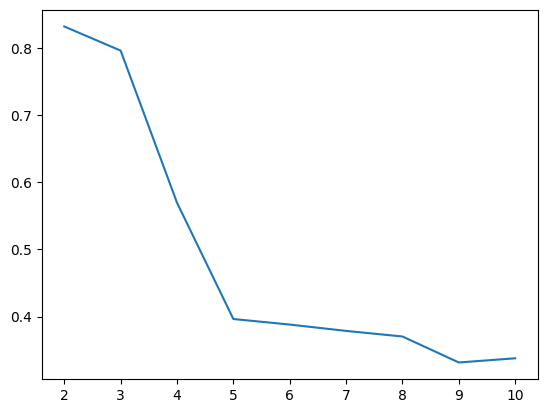

In [87]:
from tqdm import tqdm
from sklearn.metrics import silhouette_score

temp = df[["pca_x", "pca_y"]]
scores = []
for i in tqdm(range(2,11)):
    model = KMeans(n_clusters = i)
    prediction = model.fit_predict(temp)
    scores.append(silhouette_score(temp, prediction))

plt.plot(range(2,11),scores)

In [88]:
from sklearn.preprocessing import MinMaxScaler

temp = df[["pca_x", "pca_y"]]

scaler = MinMaxScaler()

col = temp.columns
temp = pd.DataFrame(scaler.fit_transform(temp), columns = col)


model = KMeans(n_clusters = 8)
temp['cluster'] = model.fit_predict(temp)
temp


,pca_x,pca_y,cluster
0,0.154335,0.424582,4
1,0.161234,0.415523,2
2,0.117641,0.435060,4
3,0.085904,0.447224,5
4,0.149257,0.408138,2
...,...,...,...
67769,0.227345,0.421808,1
67770,0.172143,0.362456,2
67771,0.272624,0.353535,7
67772,0.219591,0.318468,7


In [89]:
temp['cluster'].value_counts()

,count
cluster,
5,34527
0,21609
4,9301
1,1192
2,640
7,307
6,139
3,59


In [91]:
df['cluster']=temp['cluster']
df

,title,contents,date,token,vector,pca_x,pca_y,cluster
0,일월도서관 5060세대를 위한 인문학과 독서,프로그램명 세대를 위한 인문학과 독서 교육기간 매주 화 ...,2026. 2. 6. 15:16,"[프로그램, 세대, 위, 인문학, 독서, 교육, 기간, 총, 회, 장소, 일월, 도...","[0.081283905, -0.45355675, -0.13710701, 0.6700...",1.432845,-0.779595,4
1,일월도서관 5060세대를 위한 인문학과 독서,프로그램명 세대를 위한 인문학과 독서 교육기간 매주 화 ...,2026. 2. 6. 15:16,"[프로그램, 세대, 위, 인문학, 독서, 교육, 기간, 총, 회, 장소, 일월, 도...","[-0.03853597, -0.42289045, -0.09204495, 0.7433...",1.581421,-0.993078,2
2,"나는 무인매장으로 퇴사합니다 -5060무인매장 창업, 노후 파이프라인이 될 수 있을까?",나는무인매장으로퇴사합니다 무인매장창업 창업 무인매장고민 노후파이프라인 노후준비...,2026. 2. 12. 9:00,"[무인, 매장, 퇴사, 무인, 매장, 창업, 창업, 무인, 매장, 고민, 노후, 파...","[0.50095195, 0.24801755, -0.15919541, 0.450126...",0.642616,-0.532684,4
3,"50대, 책장을 덮고 '나'를 읽기 시작할 때 : 다산 정약용이 말하는 중년의 독서법",학이불사즉망 사이불학즉태 배우기만 하고 생각하지 않으면 얻는 것이 없고 생각만 하...,2026. 2. 2. 21:34,"[학, 불사, 즉망, 불학, 즉태, 배우다, 생각, 얻다, 생각, 배우다, 위태, ...","[-0.05474087, -0.24375252, -0.13827604, -0.081...",-0.040840,-0.246036,5
4,약 없이 혈압 잡는 기적? 5060 시니어 혈압 관리 비법 3가지,안녕하세요 년 혈압 관리의 새로운 패러다임을 제시하는 글을 읽고 계십니다 이 포...,2026. 2. 24. 15:20,"[안녕하다, 혈압, 관리, 새롭다, 패러다임, 제시, 글, 읽다, 계시다, 포스팅,...","[0.17096868, -0.706551, 0.27657604, 0.21848677...",1.323498,-1.167100,2
...,...,...,...,...,...,...,...,...
67769,혈관 뻥‼️뚫는 음식 5가지 #심장질환 #심혈관질환 #건강 #건강정보 #콜레스테롤 ...,‼️무조건 혈관에 좋은 음식 5가지‼️\n\n콜레스테롤 수치가 높아지면 혈관의 노폐...,1년 전,"[무조건, 혈관, 좋다, 음식, 가지, 콜레스테롤, 수치, 높아지다, 혈관, 노폐물...","[-0.29768983, -0.7099835, 0.07757375, -0.15291...",3.005151,-0.844972,1
67770,&quot;60대 사망률 1위 뇌졸중&quot; 독소 찌꺼기 범벅 혈관 싹 씻기는 ...,​1. 뇌졸중의 원인과 위험성\n​뇌졸중의 종류: 뇌혈관이 터지는 뇌출혈과 막히는 ...,2개월 전,"[뇌졸중, 원인, 위험성, 뇌졸중, 종류, 뇌혈관, 터지다, 뇌출혈, 막히다, 뇌경...","[1.1997999, -0.45864785, -0.5092085, -0.600456...",1.816346,-2.243593,2
67771,적당한 술은 괜찮지만 담배는 절대 금물인 이유 #뇌혈관질환,술의 수술 후 악영향:\n\n염증 악화: 알코올은 염증 반응을 촉진하고 조절 기능을...,9개월 전,"[술, 수술, 후, 악, 영향, 염증, 악화, 알코올, 염증, 반응, 촉진, 조절,...","[1.3477536, -0.37296522, 0.00862606, -0.076025...",3.980266,-2.453817,7
67772,"시니어 60대 옷장 필수템 4가지, 이 조합이면 스타일 끝! #시니어패션 #노년스타...","60대 이상이라면, 기본 아이템만 잘 갖춰도 스타일은 달라집니다.\n화이트 셔츠, ...",5개월 전,"[대다, 이상, 라면, 기본, 아이템, 자다, 갖추다, 스타일, 달라지다, 화이트,...","[1.3635617, 0.46264857, 1.5193872, 2.045785, -...",2.838171,-3.280193,7


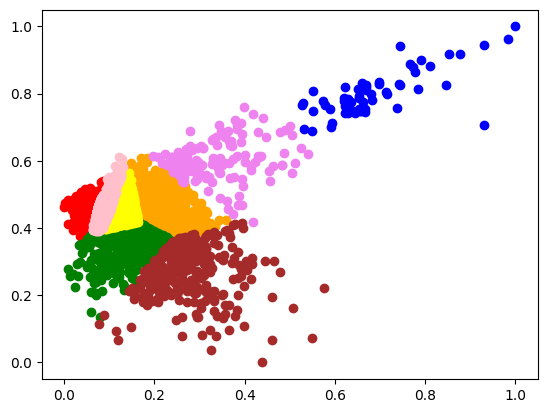

In [92]:
color = ['red','orange','green','blue','yellow','pink','violet','brown']
for i in range(8):
    t = temp[temp['cluster']==i]
    plt.scatter(t['pca_x'], t['pca_y'],color = color[i])


In [93]:
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

all_document = []
for i in df['cluster'].unique():
  temp = df.loc[df['cluster'] == i]['token']
  cluster_document = ''
  for w in temp:
    doc = " ".join(w)+' '
    cluster_document+=doc
  all_document.append(cluster_document)
all_document[0]


'프로그램 세대 위 인문학 독서 교육 기간 총 회 장소 일월 도서관 강의실 지하 층 회차 강연 인문학 문화 탐방 문화 해설 장소 덕수궁 보다 강연 참여자 접수 받다 참여 회 차갑다 많다 참석자 우선권 드리다 탐방 개별 참석 및 해체 제공 이동 수단 준비물 필기 도구 노트 주차공간 협 소하 오니 대중교통 이용 시기 바라다 일월 도서관 무인 매장 퇴사 무인 매장 창업 창업 무인 매장 고민 노후 파이프라인 노후 준비 은퇴 준비 중년 재테크 실행 가보다 길다 알 부재 인하다 고객 손해 입지 내 무인 사업 내리다 책임감 정의 무인 아이스크림 매장 보이지 기회 간절하다 붙잡다 옳다 판단 되어다 빠르다 결단 대다 블로거 맞다 현실 글쓰기 기준 의욕 지나치다 오히려 포기 하루 편 왜 힘들다 하루 이틀 쉬다 길어지다 순간 무리하다 목표 포기 지름길 대다 블로거 가장 중요하다 기준 왜 블로그 요 자주 쓰다 쓰다 것몸 마음 버티다 리듬 중요하다 써다 검색 걸리다 요 네이버 양 보다 속성 보다 여유 생기 늘리다 괜찮다 처음 하루 편 목표 안 이유 꾸준하다 빈도 보다 간격 듭 다오 늘 기준 충분하다 막연하다 노후 대한 두려움 버리다 당당하다 인생 막 주도하다 세대 활기차다 모습 새롭다 직업 자격증 취득 위해 카페 노트북 책 열공 중인 액티브 시니어 모습 인생 막 동료 가든 파티 즐기다 활기차다 소통 행복하다 시니어 모습 단순 노동 부업 한계 새롭다 대안 데이터 베다 가다 시니어 최적 이유 수익 극대 화하다 가지 실전 처방전 지금 당장 실행 액션 플랜 가장 크다 행복 사소하다 속 숨다 구글 인공 지능 서비스 미나 이용 구글 플러스 금제 우리나라 포함 개 국가 출시 밝히다 구글 제공 중년 위 사업 구조 목적 참여 자격 반드시 체크 조건 근무 기간 시간 급여 실제 체감 조건 모집 분야 예시 실제 업무 이미지 접수 선발 일정 준비 팁 안녕하다 윤 최근 저 컴퓨터 사다 뜬금 엔비디아 주식 사다 흐흣근데 왜 갑자기 엔비디아 엔비디아 뭡 맞다 시대 맞다 되어다 보고 관련 책 읽다 흐흣 영혼 돌보

In [94]:
#tf-idf vectorizer
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(all_document)

#transform to dataFrame
feature_names = vectorizer.get_feature_names_out() #vocab
tfidf = tfidf.toarray()


tfidf = pd.DataFrame(tfidf, columns = feature_names)
tfidf = tfidf.transpose() #swap row - col
tfidf

,0,1,2,3,4,5,6,7
가가,0.000730,0.000599,0.001589,0.001476,0.000718,0.000449,0.000811,0.000000
가가호호,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005450,0.000000
가감,0.000183,0.000188,0.000000,0.000000,0.000181,0.000753,0.000000,0.000404
가객,0.000000,0.000000,0.000000,0.000551,0.000000,0.000000,0.000000,0.000000
가거도,0.000000,0.000000,0.000176,0.000000,0.000000,0.000000,0.001523,0.000000
...,...,...,...,...,...,...,...,...
힙힌,0.000000,0.000000,0.000000,0.000551,0.000000,0.000000,0.000000,0.000000
힛트곡,0.000000,0.000000,0.000209,0.000000,0.000000,0.000000,0.000000,0.000000
힝공,0.000000,0.000000,0.000209,0.000000,0.000000,0.000000,0.000000,0.000000
힝링,0.000000,0.000000,0.000209,0.000000,0.000000,0.000000,0.000000,0.000000


In [95]:
for i in tfidf.columns:
  top = tfidf.sort_values(by=i,ascending = False).head(30)
  print(f'=============cluster {i}===========')
  print(top[i])
  print(f'=============cluster {i}===========')

=============cluster 0===========
임영웅     0.368511
좋다      0.286725
있다      0.236530
시간      0.184062
마음      0.170094
사랑      0.166047
추카      0.160244
읽다      0.136285
많다      0.134534
먹다      0.125488
운동      0.122577
이다      0.118263
들다      0.097618
받다      0.097326
다시      0.097180
시작      0.090987
행복하다    0.088863
노래      0.088376
오늘      0.084631
자다      0.084193
모임      0.080674
인생      0.078194
가수      0.076497
하루      0.075975
최고      0.075191
알다      0.074417
여행      0.074147
없다      0.072363
응원      0.071667
어떻다     0.071353
Name: 0, dtype: float64
=============cluster 0===========
=============cluster 1===========
임영웅     0.657396
추카      0.447539
사랑      0.121094
마음      0.119084
좋다      0.111999
스타      0.101269
아니다     0.095229
있다      0.086395
시간      0.084926
보다      0.079806
노래      0.079702
되어다     0.077560
주다      0.077261
인생      0.074076
가수      0.073674
들다      0.073368
대다      0.070823
많다      0.070074
세상      0.068048
건강      0.065235
운동      0.062020
받다     

In [96]:
#현재 클러스터 출현 빈도 / 전체 문서 빈도
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

all_document = []
for i in df['cluster'].unique():
  temp = df.loc[df['cluster'] == i]['token']
  cluster_document = ''
  for w in temp:
    doc = " ".join(w)+' '
    cluster_document+=doc
  all_document.append(cluster_document)

cnt = []
total = ''
for i in all_document:
  cnt.append(dict(Counter(i.split())))
  total += i
total = dict(Counter(total.split()))


ratio = []
for i in cnt:
  dic = {}
  for w in i:
    dic[w] = i[w]/total[w]
  ratio.append(dic)

result = pd.DataFrame()
num = 0
for a, i in zip(cnt, ratio):
  temp = pd.DataFrame({'token':list(a.keys()),'count':list(a.values()),'ratio':list(i.values())})
  temp = temp.sort_values(by="count", ascending=False).iloc[:100].sort_values(by="ratio", ascending=False).reset_index(drop = True)
  temp.columns = [f'token {num}',f'count {num}',f'ratio {num}']
  result = pd.concat([result,temp], axis = 1)
  num +=1

result.head(30)

,token 0,count 0,ratio 0,token 1,count 1,ratio 1,token 2,count 2,ratio 2,token 3,...,ratio 4,token 5,count 5,ratio 5,token 6,count 6,ratio 6,token 7,count 7,ratio 7
0,그대,327,0.418694,웅콘,234,0.639344,정동원,757,0.536879,원데이,...,0.379707,개혁,374,0.971429,준서,51,1.000000,세계테마기행,167,1.000000
1,없다,443,0.405306,추카,2670,0.523632,소나,490,0.487562,드럼,...,0.348227,전략,366,0.702495,효모,52,0.928571,한국기행,156,1.000000
2,있다,1621,0.404441,평판,325,0.513428,안되다,847,0.484277,신청,...,0.347647,트렌드,372,0.700565,작약,51,0.796875,재방,136,0.957746
3,이다,724,0.360020,트,358,0.508523,안녕하다,720,0.476506,체험,...,0.345528,연금,626,0.674569,카타르,49,0.550562,스페셜,109,0.893443
4,코스,360,0.327571,축복,273,0.476440,더,1228,0.476338,회원,...,0.333685,소비,501,0.668892,오름,104,0.512315,열리,154,0.890173
5,따뜻하다,394,0.316975,울,328,0.458741,좀,821,0.473745,참석,...,0.330063,자산,406,0.664484,나오,105,0.488372,홈페이지,1226,0.883285
6,오늘,580,0.302714,스타,756,0.449465,말,1048,0.465364,가능,...,0.329730,기업,408,0.626728,크루즈,391,0.475091,자막,1098,0.881928
7,길,573,0.300000,우주,253,0.416118,응원,1655,0.465280,무료,...,0.329353,세대,1062,0.617442,도쿄,56,0.444444,떠나,172,0.803738
8,아름답다,437,0.287500,요가,229,0.385522,축하,931,0.460435,크루즈,...,0.322977,투자,703,0.614510,다니,76,0.439306,리그,217,0.786232
9,당신,344,0.286667,연속,379,0.377114,등산,798,0.459677,등록,...,0.313194,오다,454,0.614344,느끼,61,0.414966,만나,248,0.770186


In [99]:
temp = result.head(30)
temp.iloc[:,:10]

,token 0,count 0,ratio 0,token 1,count 1,ratio 1,token 2,count 2,ratio 2,token 3
0,그대,327,0.418694,웅콘,234,0.639344,정동원,757,0.536879,원데이
1,없다,443,0.405306,추카,2670,0.523632,소나,490,0.487562,드럼
2,있다,1621,0.404441,평판,325,0.513428,안되다,847,0.484277,신청
3,이다,724,0.360020,트,358,0.508523,안녕하다,720,0.476506,체험
4,코스,360,0.327571,축복,273,0.476440,더,1228,0.476338,회원
5,따뜻하다,394,0.316975,울,328,0.458741,좀,821,0.473745,참석
6,오늘,580,0.302714,스타,756,0.449465,말,1048,0.465364,가능
7,길,573,0.300000,우주,253,0.416118,응원,1655,0.465280,무료
8,아름답다,437,0.287500,요가,229,0.385522,축하,931,0.460435,크루즈
9,당신,344,0.286667,연속,379,0.377114,등산,798,0.459677,등록


In [97]:
temp = result.head(30)
temp.iloc[:,9:]

,token 3,count 3,ratio 3,token 4,count 4,ratio 4,token 5,count 5,ratio 5,token 6,count 6,ratio 6,token 7,count 7,ratio 7
0,원데이,207,0.838057,화이팅,363,0.379707,개혁,374,0.971429,준서,51,1.000000,세계테마기행,167,1.000000
1,드럼,217,0.789091,정동원,491,0.348227,전략,366,0.702495,효모,52,0.928571,한국기행,156,1.000000
2,신청,420,0.450644,뭐,421,0.347647,트렌드,372,0.700565,작약,51,0.796875,재방,136,0.957746
3,체험,247,0.445045,고맙다,425,0.345528,연금,626,0.674569,카타르,49,0.550562,스페셜,109,0.893443
4,회원,336,0.416873,선생님,316,0.333685,소비,501,0.668892,오름,104,0.512315,열리,154,0.890173
5,참석,263,0.410296,좀,572,0.330063,자산,406,0.664484,나오,105,0.488372,홈페이지,1226,0.883285
6,가능,298,0.398929,듣다,488,0.329730,기업,408,0.626728,크루즈,391,0.475091,자막,1098,0.881928
7,무료,239,0.382400,소나,331,0.329353,세대,1062,0.617442,도쿄,56,0.444444,떠나,172,0.803738
8,크루즈,298,0.362090,치다,499,0.322977,투자,703,0.614510,다니,76,0.439306,리그,217,0.786232
9,등록,312,0.360694,제,451,0.313194,오다,454,0.614344,느끼,61,0.414966,만나,248,0.770186


In [100]:
import pickle
with open('kmeans_cluster_bindo.pkl','wb') as file:
  pickle.dump(temp,file)

In [101]:
ts = pd.read_pickle('kmeans_cluster_bindo.pkl')
ts

,token 0,count 0,ratio 0,token 1,count 1,ratio 1,token 2,count 2,ratio 2,token 3,...,ratio 4,token 5,count 5,ratio 5,token 6,count 6,ratio 6,token 7,count 7,ratio 7
0,그대,327,0.418694,웅콘,234,0.639344,정동원,757,0.536879,원데이,...,0.379707,개혁,374,0.971429,준서,51,1.000000,세계테마기행,167,1.000000
1,없다,443,0.405306,추카,2670,0.523632,소나,490,0.487562,드럼,...,0.348227,전략,366,0.702495,효모,52,0.928571,한국기행,156,1.000000
2,있다,1621,0.404441,평판,325,0.513428,안되다,847,0.484277,신청,...,0.347647,트렌드,372,0.700565,작약,51,0.796875,재방,136,0.957746
3,이다,724,0.360020,트,358,0.508523,안녕하다,720,0.476506,체험,...,0.345528,연금,626,0.674569,카타르,49,0.550562,스페셜,109,0.893443
4,코스,360,0.327571,축복,273,0.476440,더,1228,0.476338,회원,...,0.333685,소비,501,0.668892,오름,104,0.512315,열리,154,0.890173
5,따뜻하다,394,0.316975,울,328,0.458741,좀,821,0.473745,참석,...,0.330063,자산,406,0.664484,나오,105,0.488372,홈페이지,1226,0.883285
6,오늘,580,0.302714,스타,756,0.449465,말,1048,0.465364,가능,...,0.329730,기업,408,0.626728,크루즈,391,0.475091,자막,1098,0.881928
7,길,573,0.300000,우주,253,0.416118,응원,1655,0.465280,무료,...,0.329353,세대,1062,0.617442,도쿄,56,0.444444,떠나,172,0.803738
8,아름답다,437,0.287500,요가,229,0.385522,축하,931,0.460435,크루즈,...,0.322977,투자,703,0.614510,다니,76,0.439306,리그,217,0.786232
9,당신,344,0.286667,연속,379,0.377114,등산,798,0.459677,등록,...,0.313194,오다,454,0.614344,느끼,61,0.414966,만나,248,0.770186
